In [16]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version PyTorch is using: {torch.version.cuda}")
print(f"Is the GPU recognized? {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cu130
CUDA version PyTorch is using: 13.0
Is the GPU recognized? True


In [17]:
import os
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

## Configuration

In [18]:
ZIP_PATH = Path("train_processed_final.zip")     
LABELS_CSV = Path("trainLabels.csv")             
EXTRACT_DIR = Path("train_processed_data")       
MODEL_SAVE_PATH = Path("best_convnext_tiny.pth")

NUM_CLASSES = 5
BATCH_SIZE = 32
NUM_EPOCHS = 10
LR = 1e-4
WEIGHT_DECAY = 1e-4
VAL_SIZE = 0.2
NUM_WORKERS = 0
IMG_SIZE = 224

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [19]:
if not EXTRACT_DIR.exists():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

Dataset already extracted.


In [20]:
labels_df = pd.read_csv(LABELS_CSV)
print(labels_df.head())
print(labels_df.columns.tolist())

      image  level
0   10_left      0
1  10_right      0
2   13_left      0
3  13_right      0
4   15_left      1
['image', 'level']


## Image path mapping

In [21]:
image_files = list(EXTRACT_DIR.rglob("*.jpg")) + list(EXTRACT_DIR.rglob("*.jpeg")) + list(EXTRACT_DIR.rglob("*.png"))
print("Total extracted image files:", len(image_files))
image_map = {img.stem: img for img in image_files}
print("Mapped image stems:", len(image_map))

Total extracted image files: 35126
Mapped image stems: 35126


## Match labels with available images

In [22]:
labels_df["image_path"] = labels_df["image"].map(image_map)
labels_df = labels_df.dropna(subset=["image_path"]).copy()

labels_df["image_path"] = labels_df["image_path"].astype(str)
labels_df["level"] = labels_df["level"].astype(int)

print("Matched samples:", len(labels_df))
print(labels_df["level"].value_counts().sort_index())
labels_df.head()

Matched samples: 35126
level
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64


,image,level,image_path
0,10_left,0,train_processed_data\10_left.jpg
1,10_right,0,train_processed_data\10_right.jpg
2,13_left,0,train_processed_data\13_left.jpg
3,13_right,0,train_processed_data\13_right.jpg
4,15_left,1,train_processed_data\15_left.jpg


In [23]:
train_df, val_df = train_test_split(
    labels_df,
    test_size = VAL_SIZE,
    stratify = labels_df["level"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

Train size: 28100
Val size: 7026


In [24]:
train_df.to_csv("train_dataset.csv", index=False)
val_df.to_csv("val_dataset.csv", index=False)

In [29]:
train_df = pd.read_csv("train_dataset.csv")   
val_df = pd.read_csv("val_dataset.csv")   

## Data Augmentation

In [30]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.RandomRotation(degrees = 10),
    transforms.ColorJitter(brightness = 0.1, contrast = 0.1, saturation = 0.05, hue = 0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean = [0.485, 0.456, 0.406],
                         std = [0.229, 0.224, 0.225])
])

## Creating Dataset

In [31]:
class DRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["image_path"]
        label = int(self.df.iloc[idx]["level"])
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Failed to load image: {img_path}") from e
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = DRDataset(train_df, transform=train_transform)
val_dataset = DRDataset(val_df, transform=val_transform)

## Handling Class Imbalance
Ref: <href>https://www.geeksforgeeks.org/deep-learning/handling-class-imbalance-in-pytorch/</href>

In [32]:
class_counts = train_df["level"].value_counts().sort_index().values
class_weights = 1.0 / class_counts
sample_weights = train_df["level"].map(lambda x: class_weights[x]).values

sampler = WeightedRandomSampler(
    weights = torch.DoubleTensor(sample_weights),
    num_samples = len(sample_weights),
    replacement = True
)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [20648  1954  4234   698   566]
Class weights: [4.84308408e-05 5.11770727e-04 2.36183278e-04 1.43266476e-03
 1.76678445e-03]


## Data Loaders
Ref: <href>https://docs.pytorch.org/docs/stable/data.html</href>

In [33]:
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    sampler = sampler,
    num_workers = NUM_WORKERS,
    pin_memory = True,
    persistent_workers = False,
    prefetch_factor = None
)

val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = NUM_WORKERS,
    pin_memory = True,
    persistent_workers = False,
    prefetch_factor = None
)

## Loading ConvNeXt-Tiny
Using pre-trained weights

In [34]:
weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights = weights)

in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(DEVICE)
print(model)

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

## Loss, Optimizer, Scheduler, Mixed Precision

In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(
    model.parameters(),
    lr = LR,
    weight_decay = WEIGHT_DECAY
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = "max",
    factor = 0.5,
    patience = 2
)
scaler = torch.amp.GradScaler(enabled = (DEVICE.type == "cuda"))

## Model Training

In [36]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc = "Training", leave = True, ascii = True)

    for images, labels in pbar:
        images = images.to(device, non_blocking = True)
        labels = labels.to(device, non_blocking = True)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type = "cuda", enabled = (device.type == "cuda")):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        pbar.set_postfix(loss = loss.item())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average = "weighted")

    return epoch_loss, epoch_acc, epoch_f1


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        pbar = tqdm(loader, desc = "Validation", leave = True, ascii = True)

        for images, labels in pbar:
            images = images.to(device, non_blocking = True)
            labels = labels.to(device, non_blocking = True)

            with torch.amp.autocast(device_type = "cuda", enabled = (device.type == "cuda")):
                outputs = model(images)
                loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average = "weighted")

    return epoch_loss, epoch_acc, epoch_f1, all_labels, all_preds

In [23]:
history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}

best_val_f1 = 0.0

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")

    train_loss, train_acc, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, DEVICE
    )

    val_loss, val_acc, val_f1, val_labels, val_preds = validate_one_epoch(
        model, val_loader, criterion, DEVICE
    )

    scheduler.step(val_f1)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Best model saved to: {MODEL_SAVE_PATH}")


Epoch [1/10]


Validation: 100%|####################################################################| 220/220 [01:21<00:00,  2.68it/s]


Train Loss: 0.9706 | Train Acc: 0.5723 | Train F1: 0.5707
Val Loss: 1.1614 | Val Acc: 0.4426 | Val F1: 0.5042
Best model saved to: best_convnext_tiny.pth

Epoch [2/10]


Validation: 100%|####################################################################| 220/220 [00:34<00:00,  6.31it/s]


Train Loss: 0.6358 | Train Acc: 0.7200 | Train F1: 0.7188
Val Loss: 0.7719 | Val Acc: 0.7427 | Val F1: 0.7378
Best model saved to: best_convnext_tiny.pth

Epoch [3/10]


...

Train Loss: 0.1363 | Train Acc: 0.9491 | Train F1: 0.9490
Val Loss: 1.0598 | Val Acc: 0.7254 | Val F1: 0.7284

Epoch [9/10]


Validation: 100%|####################################################################| 220/220 [00:29<00:00,  7.40it/s]


Train Loss: 0.0972 | Train Acc: 0.9660 | Train F1: 0.9659
Val Loss: 1.0347 | Val Acc: 0.7623 | Val F1: 0.7510
Best model saved to: best_convnext_tiny.pth

Epoch [10/10]


Validation: 100%|####################################################################| 220/220 [00:29<00:00,  7.50it/s]


Train Loss: 0.0816 | Train Acc: 0.9720 | Train F1: 0.9720
Val Loss: 1.1133 | Val Acc: 0.7716 | Val F1: 0.7524
Best model saved to: best_convnext_tiny.pth


## Plot training history

In [53]:
import pandas as pd
from pathlib import Path

# history_df = pd.read_csv("training_history.csv") 
history_df = pd.DataFrame(history)
history_df.index = history_df.index + 1
history_df.index.name = "epoch"

history_csv_path = Path("training_history.csv")
history_df.to_csv(history_csv_path, index=True)

print("Saved history to:", history_csv_path.resolve())
history_df.head()

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,0.970621,0.572313,0.570651,1.161371,0.442642,0.504155
1,2,0.635846,0.720036,0.718768,0.771865,0.742670,0.737823
2,3,0.489194,0.789573,0.789244,0.855161,0.694990,0.707568
3,4,0.401165,0.834698,0.834440,1.021482,0.577569,0.633311
4,5,0.324594,0.869715,0.869485,0.916525,0.673214,0.696920


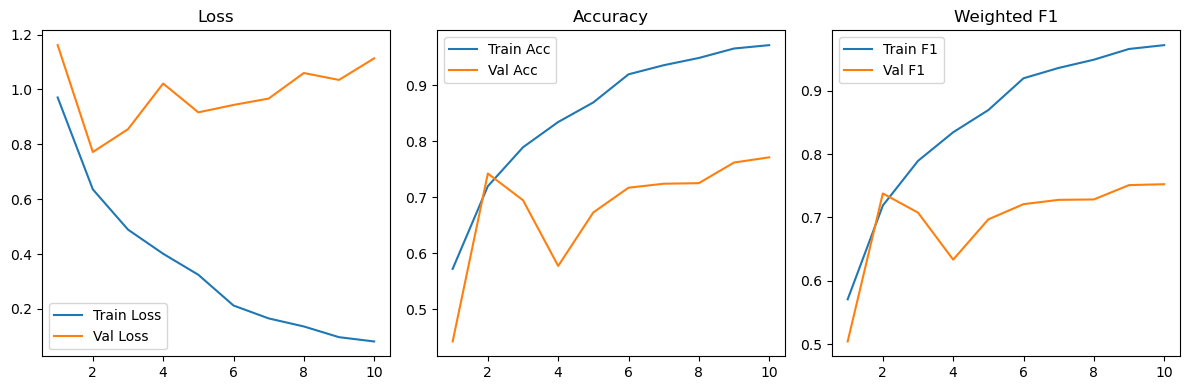

In [25]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, history["train_f1"], label="Train F1")
plt.plot(epochs, history["val_f1"], label="Val F1")
plt.title("Weighted F1")
plt.legend()

plt.tight_layout()
plt.show()

## Load best model and evaluate

In [38]:
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location = DEVICE))
model.eval()

val_loss, val_acc, val_f1, val_labels, val_preds = validate_one_epoch(
    model, val_loader, criterion, DEVICE
)

print("Best Validation Accuracy:", val_acc)
print("Best Validation Weighted F1:", val_f1)

Validation: 100%|####################################################################| 220/220 [01:04<00:00,  3.41it/s]

Best Validation Accuracy: 0.9362368346142897
Best Validation Weighted F1: 0.9366797334961888


## Classification Report

In [27]:
print(classification_report(val_labels, val_preds, digits=4))

              precision    recall  f1-score   support

           0     0.8500    0.9082    0.8781      5162
           1     0.2229    0.0716    0.1084       489
           2     0.5067    0.5378    0.5218      1058
           3     0.4874    0.3314    0.3946       175
           4     0.6339    0.5000    0.5591       142

    accuracy                         0.7716      7026
   macro avg     0.5402    0.4698    0.4924      7026
weighted avg     0.7413    0.7716    0.7524      7026



## Confusion Matrix

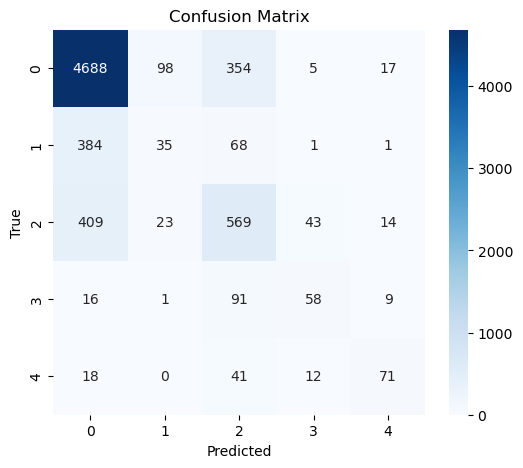

In [28]:
cm = confusion_matrix(val_labels, val_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2,3,4],
            yticklabels=[0,1,2,3,4])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Normalised Confusion Matrix

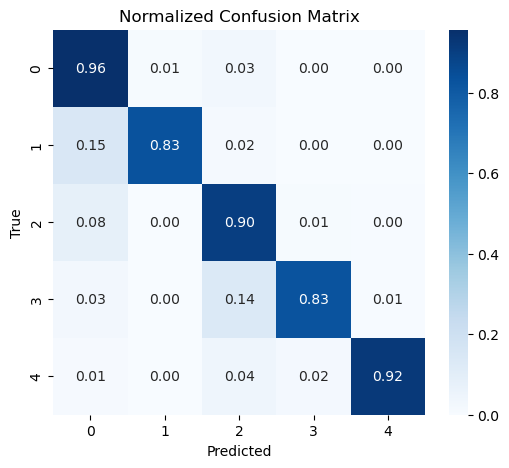

In [39]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(val_labels, val_preds, labels=[0,1,2,3,4])
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=[0,1,2,3,4],
    yticklabels=[0,1,2,3,4]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()

## Support per class bar chart

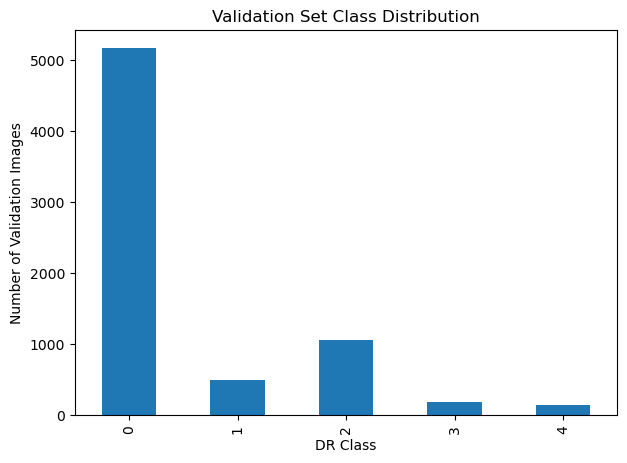

In [40]:
val_df["level"].value_counts().sort_index().plot(kind="bar", figsize=(7,5))
plt.xlabel("DR Class")
plt.ylabel("Number of Validation Images")
plt.title("Validation Set Class Distribution")
plt.show()

## Pre-class Error rate plot

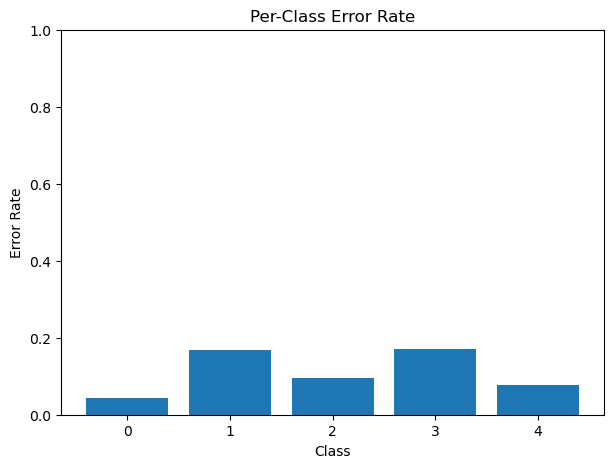

In [43]:
error_rate = 1 - (class_stats["sum"] / class_stats["count"])

plt.figure(figsize=(7,5))
plt.bar(error_rate.index.astype(str), error_rate.values)
plt.xlabel("Class")
plt.ylabel("Error Rate")
plt.ylim(0, 1)
plt.title("Per-Class Error Rate")
plt.show()

## Pre-class Recall

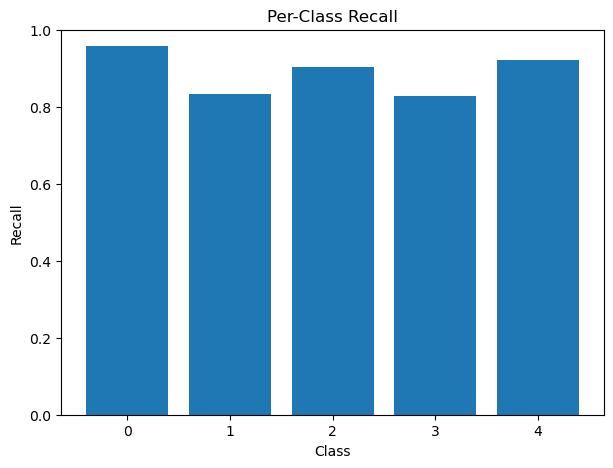

In [57]:
class_recall = class_stats["sum"] / class_stats["count"]

plt.figure(figsize=(7,5))
plt.bar(class_recall.index.astype(str), class_recall.values)
plt.xlabel("Class")
plt.ylabel("Recall")
plt.ylim(0,1)
plt.title("Per-Class Recall")
plt.show()

## Per-class Precision / Recall / F1 Bar Chart

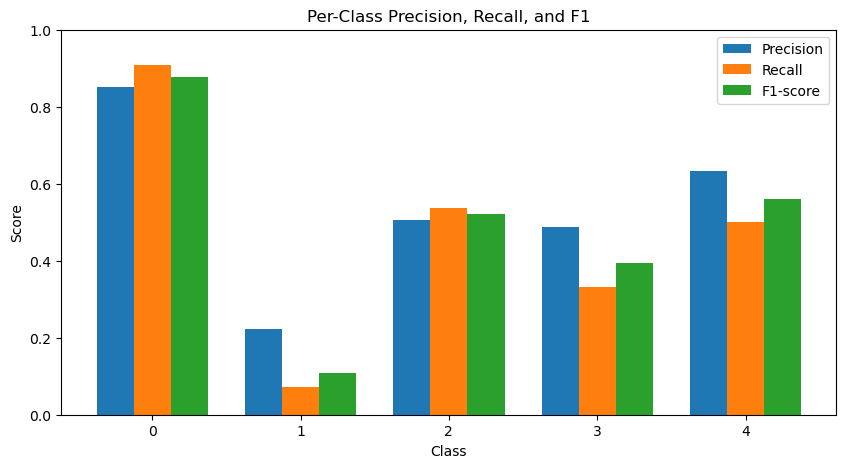

In [29]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

precision, recall, f1, _ = precision_recall_fscore_support(
    val_labels, val_preds, labels=[0,1,2,3,4], zero_division=0
)

classes = ['0', '1', '2', '3', '4']
x = np.arange(len(classes))
width = 0.25

plt.figure(figsize=(10, 5))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1, width, label='F1-score')

plt.xticks(x, classes)
plt.ylim(0, 1)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall, and F1")
plt.legend()
plt.show()

## Class Distribution Plot

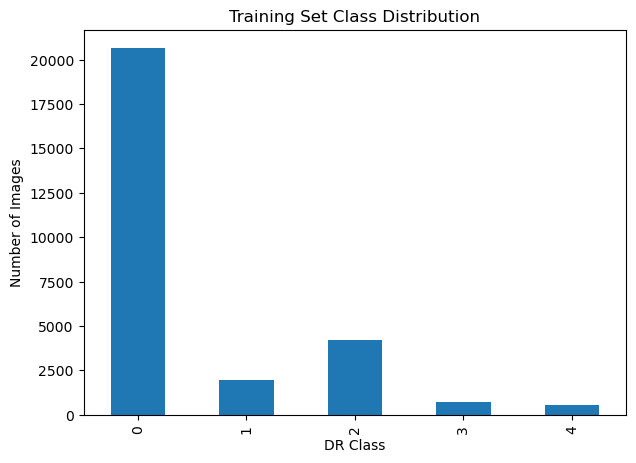

In [30]:
train_df["level"].value_counts().sort_index().plot(kind="bar", figsize=(7,5))
plt.xlabel("DR Class")
plt.ylabel("Number of Images")
plt.title("Training Set Class Distribution")
plt.show()

## Prediction distribution vs true distribution

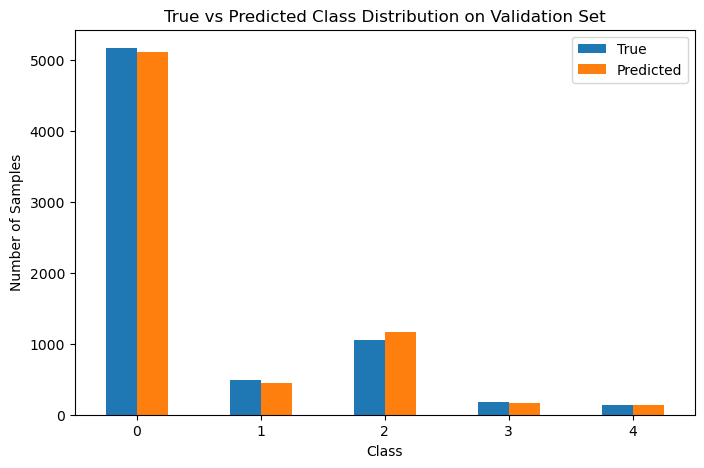

In [44]:
true_counts = pd.Series(val_labels).value_counts().sort_index()
pred_counts = pd.Series(val_preds).value_counts().sort_index()

dist_df = pd.DataFrame({
    "True": true_counts,
    "Predicted": pred_counts
}).fillna(0)

dist_df.plot(kind="bar", figsize=(8,5))
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("True vs Predicted Class Distribution on Validation Set")
plt.xticks(rotation=0)
plt.show()

## Sample Predictions Grid

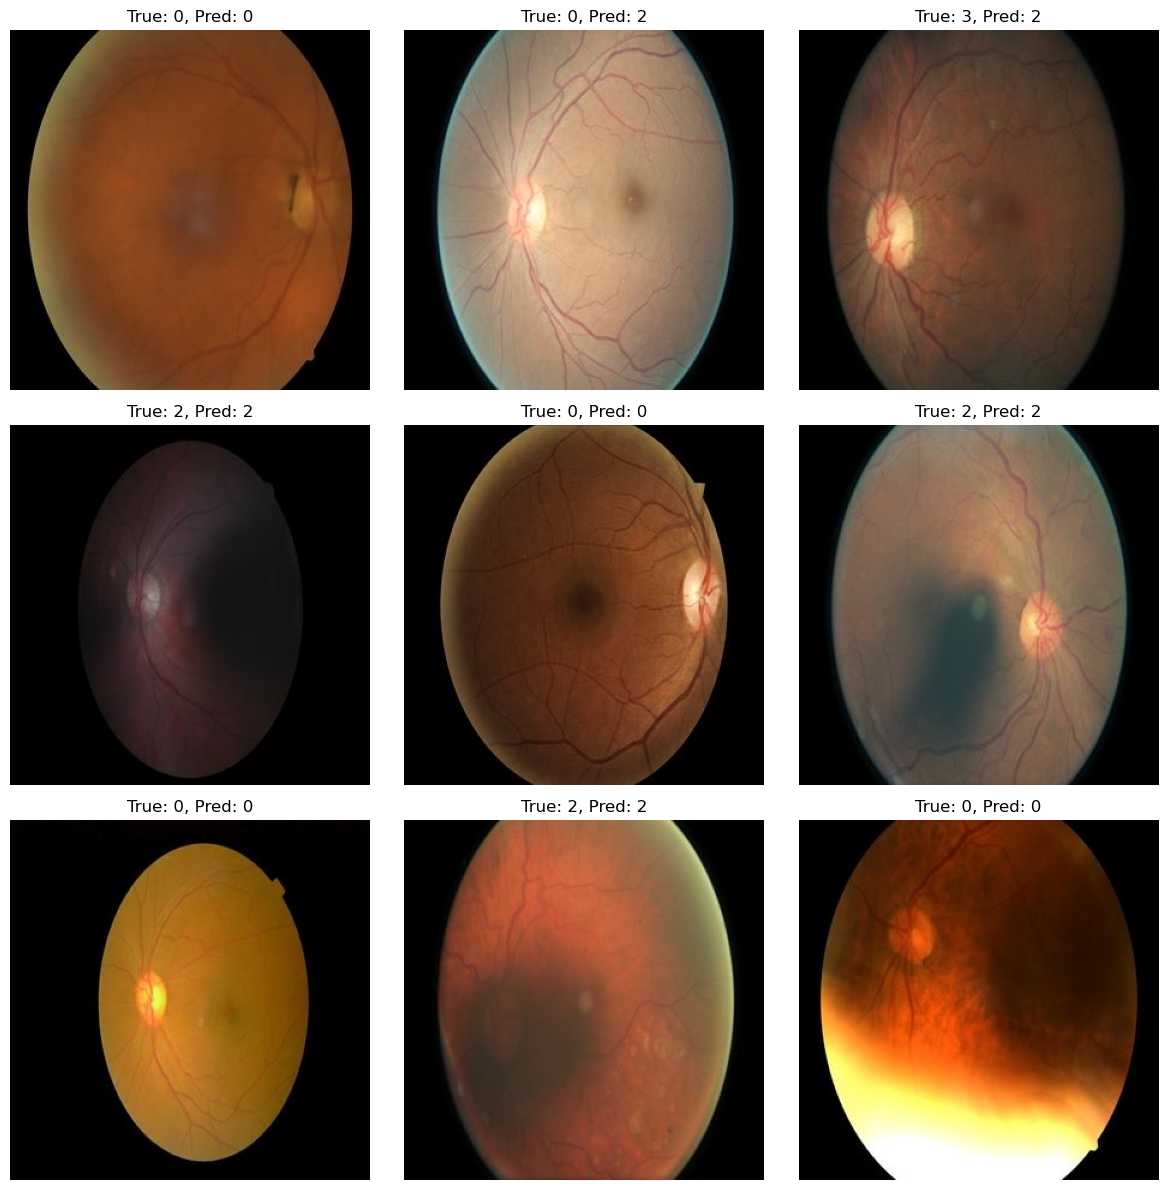

In [33]:
import random
from PIL import Image

sample_indices = random.sample(range(len(val_df)), 9)

plt.figure(figsize=(12, 12))
for i, idx in enumerate(sample_indices, 1):
    row = val_df.iloc[idx]
    img = Image.open(row["image_path"]).convert("RGB")

    # you need corresponding prediction list aligned with val_df
    true_label = row["level"]
    pred_label = val_preds[idx]

    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(f"True: {true_label}, Pred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Misclassified Predictions Grid

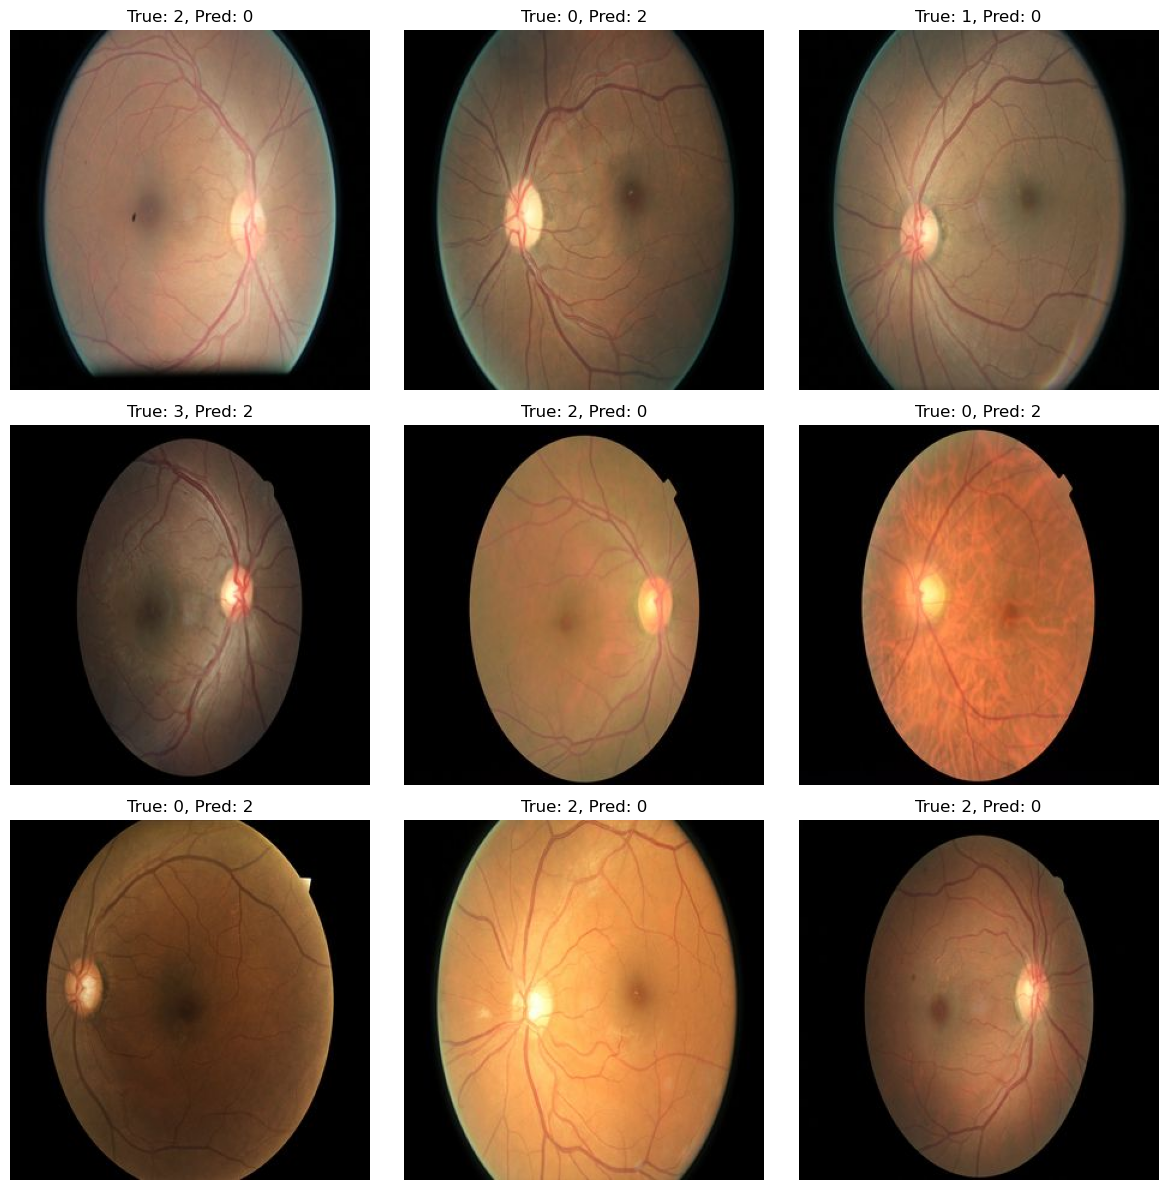

In [34]:
mis_idx = [i for i, (t, p) in enumerate(zip(val_labels, val_preds)) if t != p][:9]

plt.figure(figsize=(12, 12))
for i, idx in enumerate(mis_idx, 1):
    row = val_df.iloc[idx]
    img = Image.open(row["image_path"]).convert("RGB")

    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(f"True: {row['level']}, Pred: {val_preds[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [58]:
results_df = pd.DataFrame({
    "true": val_labels,
    "pred": val_preds
})

mistakes = results_df[results_df["true"] != results_df["pred"]]
pair_counts = mistakes.groupby(["true", "pred"]).size().sort_values(ascending=False)

print(pair_counts.head(10))

true  pred
0     2       172
2     0        87
1     0        72
0     1        46
3     2        24
2     3        11
1     2         9
4     2         6
3     0         5
2     4         4
dtype: int64


## Misclassification flow heatmap

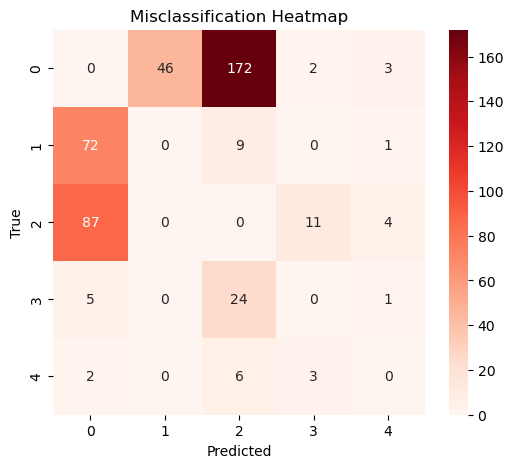

In [46]:
cm = confusion_matrix(val_labels, val_preds, labels=[0,1,2,3,4])
cm_offdiag = cm.copy()
np.fill_diagonal(cm_offdiag, 0)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_offdiag,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=[0,1,2,3,4],
    yticklabels=[0,1,2,3,4]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Misclassification Heatmap")
plt.show()

## Correct vs incorrect predictions by class

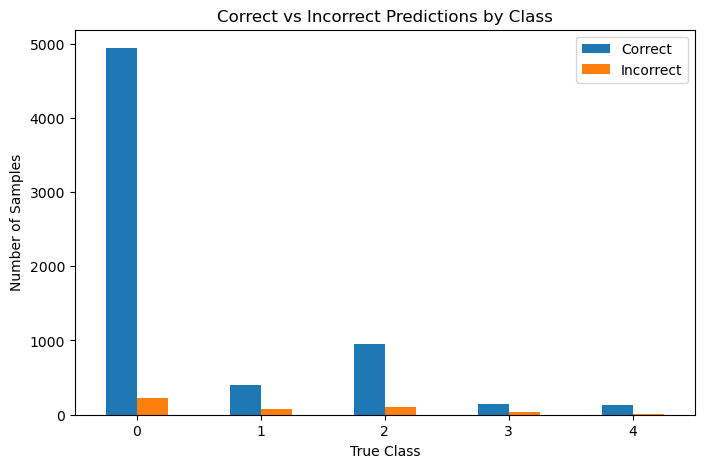

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results_df = pd.DataFrame({
    "true": val_labels,
    "pred": val_preds
})
results_df["correct"] = results_df["true"] == results_df["pred"]

class_stats = results_df.groupby("true")["correct"].agg(["sum", "count"])
class_stats["incorrect"] = class_stats["count"] - class_stats["sum"]

class_stats[["sum", "incorrect"]].plot(
    kind="bar",
    figsize=(8,5)
)
plt.xlabel("True Class")
plt.ylabel("Number of Samples")
plt.title("Correct vs Incorrect Predictions by Class")
plt.legend(["Correct", "Incorrect"])
plt.xticks(rotation=0)
plt.show()

## Generalised Gap Plot

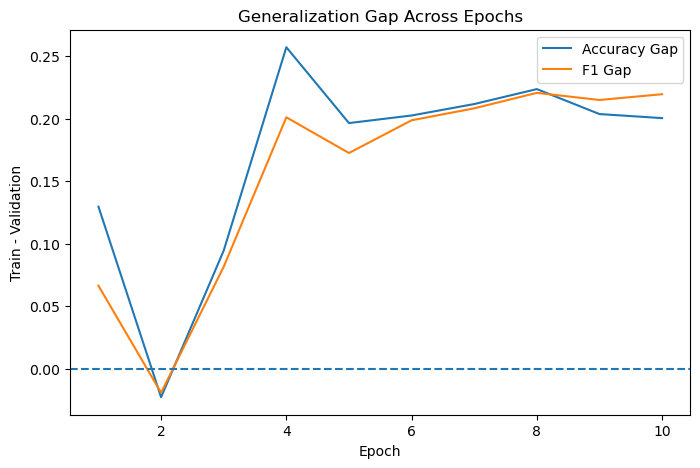

In [50]:
gap_acc = np.array(history_df["train_acc"]) - np.array(history_df["val_acc"])
gap_f1 = np.array(history_df["train_f1"]) - np.array(history_df["val_f1"])

epochs = range(1, len(gap_acc) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, gap_acc, label="Accuracy Gap")
plt.plot(epochs, gap_f1, label="F1 Gap")
plt.axhline(0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Train - Validation")
plt.title("Generalization Gap Across Epochs")
plt.legend()
plt.show()

## Epoch-to-Epoch Improvement Graphs

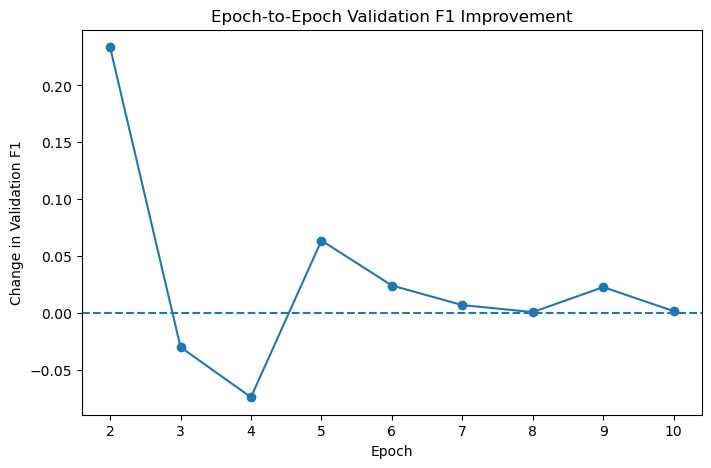

In [51]:
val_f1 = np.array(history_df["val_f1"])
delta_val_f1 = np.diff(val_f1)

plt.figure(figsize=(8,5))
plt.plot(range(2, len(val_f1)+1), delta_val_f1, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Change in Validation F1")
plt.title("Epoch-to-Epoch Validation F1 Improvement")
plt.show()

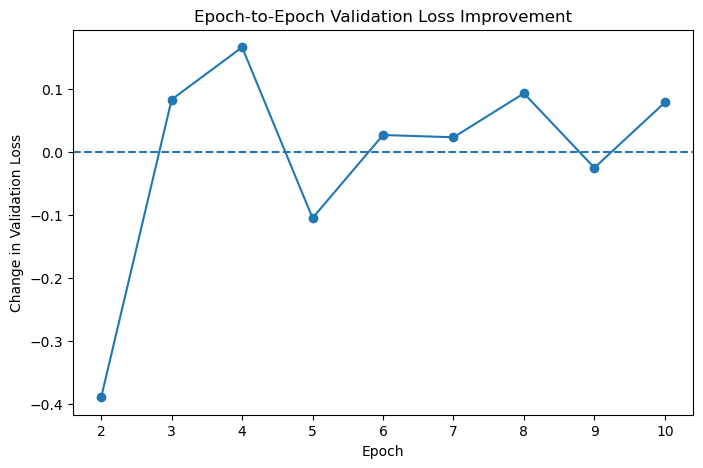

In [54]:
val_loss = np.array(history_df["val_loss"])
delta_val_loss = np.diff(val_loss)

plt.figure(figsize=(8,5))
plt.plot(range(2, len(val_f1)+1), delta_val_loss, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Change in Validation Loss")
plt.title("Epoch-to-Epoch Validation Loss Improvement")
plt.show()

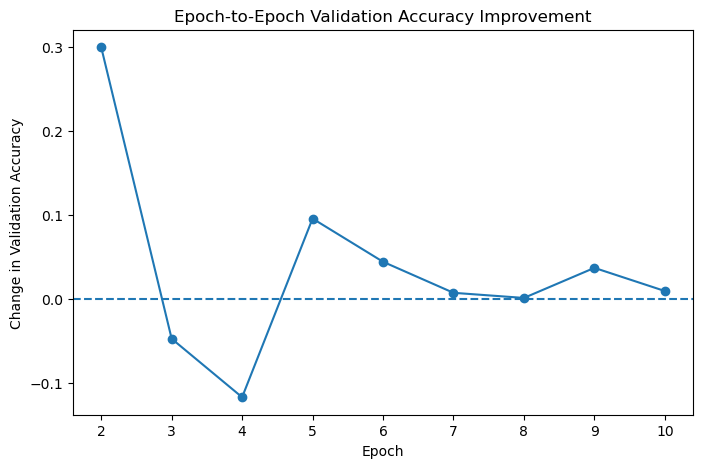

In [55]:
val_acc = np.array(history_df["val_acc"])
delta_val_acc = np.diff(val_acc)

plt.figure(figsize=(8,5))
plt.plot(range(2, len(val_f1)+1), delta_val_acc, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Change in Validation Accuracy")
plt.title("Epoch-to-Epoch Validation Accuracy Improvement")
plt.show()

In [21]:
img, label = train_dataset[0]
print(type(img), img.shape, label)

<class 'torch.Tensor'> torch.Size([3, 224, 224]) 0


In [22]:
batch = next(iter(train_loader))
images, labels = batch
print(images.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32])
